## Energy Savings App

The Energy Saving Application is a comprehensive, modular pipeline designed to train and deploy a Reinforcement Learning (RL) agent for dynamic network optimization. The core objective is to significantly reduce power consumption by intelligently turning cell sectors on or off and adjusting their antenna tilts based on the time of day, while maintaining acceptable network coverage and Quality of Service (QoS).

This system leverages a pre-trained Bayesian Digital Twin (BDT) RF model, which allows the RL training loop to perform rapid, local RF simulations. This architecture decouples the RL agent's learning process from the latency of live backend services, enabling efficient training on multi-day traffic patterns. The entire workflow is orchestrated through a main application with a clear command-line interface.

In [1]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [2]:
import logging
import os
from IPython.display import Image, display

from apps.energy_saving_app.data_preprocessor import UEDataPreprocessor
from apps.energy_saving_app.bdt_manager import BDTManager
from apps.energy_saving_app.rl_trainer import run_rl_training
from apps.energy_saving_app.rl_predictor import run_rl_prediction
from apps.energy_saving_app.energy_saving_visualizer import EnergySavingVisualizer

In [3]:
# --- Logging Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Setting up Data Directory & Save Locations

*unzip the `data/eneregy_saving_data.zip` file to get `data/energy_saving_data/` folder*

In [4]:
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

BASE_DATA_DIR = os.path.join(NOTEBOOK_DIR, "data", "energy_saving_data", "generated_data")
STATIC_DATA_DIR = os.path.join(NOTEBOOK_DIR, "data", "energy_saving_data", "data")

In [ ]:
# All relevant data required for this demo are located in the following directories
TOPOLOGY_PATH = os.path.join(STATIC_DATA_DIR, "topology.csv")
CONFIG_PATH = os.path.join(STATIC_DATA_DIR, "config.csv")
TRAINING_DATA_PATH = os.path.join(STATIC_DATA_DIR, "dummy_ue_training_data.csv")

# All data saved during the training and prediction processes are located in the following directories
BDT_MODEL_PATH = os.path.join("data", "energy_saving_data", "bdt_model_map.pickle")
RL_MODEL_PATH = os.path.join("data", "energy_saving_data", "energy_saver_agent.zip")
RL_LOG_DIR = os.path.join("data", "energy_saving_data", "rl_training_logs")
PLOT_OUTPUT_DIR = os.path.join(STATIC_DATA_DIR, "plots")

# Showcasing **Energy Savings** Functions: 

Define the ``TRAIN_DAYS`` and ``test_day`` days, **optionally** ``TOTAL_TIMESTEPS``

In [7]:
TRAIN_DAYS = [0, 1, 2, 3]
test_day = 4
days_to_process = sorted(set(TRAIN_DAYS + [test_day]))
TOTAL_TIMESTEPS = 1000

### 1. Preprocessing all `User Equipement` **(UE)** Data
Preprocessing of raw UE data CSV files is performed to ensure compatibility with the RL Gym environment

In [8]:
# 500 UEs x 24 ticks x 5 days = 60000 total data points
logger.info(f"--- Running UE Data Preprocessing for days: {days_to_process} ---")
preprocessor = UEDataPreprocessor(base_data_dir=BASE_DATA_DIR)
preprocessor.run(days=days_to_process)
logger.info("--- Preprocessing Step Finished ---")

2025-06-26 11:45:33,686 - __main__ - INFO - --- Running UE Data Preprocessing for days: [0, 1, 2, 3, 4] ---
2025-06-26 11:45:33,688 - apps.energy_saving_app.data_preprocessor - INFO - Processing 24 files for Day_0...
2025-06-26 11:45:34,015 - apps.energy_saving_app.data_preprocessor - INFO - Finished preprocessing for Day_0. Processed 24/24 files into 'c:\Users\rafid\OneDrive\Desktop\VSCode\maveric\notebooks\data\energy_saving_data\generated_data\Day_0\ue_data_gym_ready'.
2025-06-26 11:45:34,017 - apps.energy_saving_app.data_preprocessor - INFO - Processing 24 files for Day_1...
2025-06-26 11:45:34,353 - apps.energy_saving_app.data_preprocessor - INFO - Finished preprocessing for Day_1. Processed 24/24 files into 'c:\Users\rafid\OneDrive\Desktop\VSCode\maveric\notebooks\data\energy_saving_data\generated_data\Day_1\ue_data_gym_ready'.
2025-06-26 11:45:34,353 - apps.energy_saving_app.data_preprocessor - INFO - Processing 24 files for Day_2...
2025-06-26 11:45:34,703 - apps.energy_saving_

### 2. Training core `bayesian_digital_twins` **(BDT)**
Calls for the training of the Bayesian Digital Twin model, as well as the downloading of the resulting model

In [9]:
# Set parameters
BDT_MODEL_ID = "bdt_for_energy_saving"
CONTAINER_NAME = "radp_dev-training-1"

In [10]:
# Train bayesian_digital_twins from scratch
logger.info("--- Running BDT Training ---")
bdt_manager = BDTManager(
    topology_path=TOPOLOGY_PATH,
    training_data_path=TRAINING_DATA_PATH,
    model_path=BDT_MODEL_PATH
)
bdt_manager.train(model_id=BDT_MODEL_ID, container_name=CONTAINER_NAME)
logger.info("--- BDT Training Finished ---")

2025-06-26 12:13:09,203 - __main__ - INFO - --- Running BDT Training ---
2025-06-26 12:13:09,204 - apps.energy_saving_app.bdt_manager - INFO - Initiating BDT model training for model_id: bdt_for_energy_saving...
2025-06-26 12:13:09,204 - apps.energy_saving_app.bdt_manager - INFO - Loading topology from c:\Users\rafid\OneDrive\Desktop\VSCode\maveric\notebooks\data\energy_saving_data\data\topology.csv
2025-06-26 12:13:09,217 - apps.energy_saving_app.bdt_manager - INFO - Loading training data from c:\Users\rafid\OneDrive\Desktop\VSCode\maveric\notebooks\data\energy_saving_data\data\dummy_ue_training_data.csv
2025-06-26 12:13:10,411 - apps.energy_saving_app.bdt_manager - INFO - Training request sent for model_id: bdt_for_energy_saving. Waiting for completion...


Model not yet trained
Waiting 30 seconds


2025-06-26 12:13:40,450 - apps.energy_saving_app.bdt_manager - INFO - BDT model 'bdt_for_energy_saving' trained successfully in backend.
2025-06-26 12:13:40,451 - apps.energy_saving_app.bdt_manager - INFO - Attempting to download model from 'radp_dev-training-1:/srv/radp/models/bdt_for_energy_saving/model.pickle' to 'data\energy_saving_data\bdt_model_map.pickle'...


Model training job complete!


2025-06-26 12:13:42,189 - apps.energy_saving_app.bdt_manager - INFO - Model downloaded successfully from Docker container.
2025-06-26 12:13:42,190 - __main__ - INFO - --- BDT Training Finished ---


### 3. Train `RL Agent` for **Energy Savings** on The First 4 Days
- Initialize and train a `reinforcement learning` (RL) agent for energy-saving applications with an environment set up using site `configuration` & `UE` data, and a `BDT` model.
- Log monitors training process & saves checkpoints periodically

In [11]:
# Intialize and train RL agent
logger.info(f"--- Running RL Training on Days: {TRAIN_DAYS} ---")
run_rl_training(
    bdt_model_path=BDT_MODEL_PATH,
    base_ue_data_dir=BASE_DATA_DIR,
    training_days=TRAIN_DAYS,
    topology_path=TOPOLOGY_PATH,
    config_path=CONFIG_PATH,
    rl_model_path=RL_MODEL_PATH,
    log_dir=RL_LOG_DIR,
    total_timesteps=TOTAL_TIMESTEPS
)
logger.info("--- RL Training Finished ---")

2025-06-26 12:31:42,904 - __main__ - INFO - --- Running RL Training on Days: [0, 1, 2, 3] ---
2025-06-26 12:31:42,904 - apps.energy_saving_app.rl_trainer - INFO - --- Starting RL Energy Saver Training ---
2025-06-26 12:31:45,609 - apps.energy_saving_app.rl_trainer - INFO - Loaded BDT map for 15 cells.
2025-06-26 12:31:46,607 - apps.energy_saving_app.rl_energy_saving_env - INFO - TickAwareEnergyEnv initialized for 15 cells.


Using cuda device
Wrapping the env in a DummyVecEnv.


2025-06-26 12:31:48,596 - apps.energy_saving_app.rl_trainer - INFO - Starting RL training for 1000 timesteps...


Logging to data\energy_saving_data\rl_training_logs\PPO_EnergySaver_1


[2025-06-26 12:31:49,413] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,519] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,539] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,553] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,570] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,583] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,596] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,606] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,620] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,630] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,641] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,654] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,667] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,680] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:49,692] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:50,056] INFO:  Cuda enabled for test data.
[2025-06-26 12:31:50,066

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 168      |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 2        |
|    iterations      | 1        |
|    time_elapsed    | 930      |
|    total_timesteps | 2048     |
---------------------------------


2025-06-26 12:47:25,975 - apps.energy_saving_app.rl_trainer - INFO - Training complete. Model saved to data\energy_saving_data\energy_saver_agent.zip
2025-06-26 12:47:25,976 - __main__ - INFO - --- RL Training Finished ---


### 4. Inference
- Loads `RL agent` and predicts the optimal cell configuration, including `tilt angles` and `on/off states`, for energy-saving applications. 
- Prediction is performed for a specified `time tick` (hour). 

In [13]:
# Set inference tick
TICK = 18
TEST_DAY = 4

In [14]:
# Run inference on exising RL model
logger.info(f"--- Running Inference for Tick {TICK} ---")
run_rl_prediction(
    model_load_path=RL_MODEL_PATH,
    topology_path=TOPOLOGY_PATH,
    target_tick=TICK
)
logger.info("--- Inference Step Finished ---")

2025-06-26 12:55:12,143 - __main__ - INFO - --- Running Inference for Tick 18 ---
2025-06-26 12:55:12,143 - apps.energy_saving_app.rl_predictor - INFO - --- Running RL Energy Saver Prediction for Tick 18 ---
2025-06-26 12:55:12,181 - apps.energy_saving_app.rl_predictor - INFO - Loaded trained RL model from data\energy_saving_data\energy_saver_agent.zip
2025-06-26 12:55:12,198 - __main__ - INFO - --- Inference Step Finished ---



--- Predicted Optimal Configuration ---
--- For Tick/Hour: 18 ---
 cell_id predicted_state predicted_cell_el_deg
cell_1_0              ON                   0.0
cell_1_1              ON                  18.0
cell_1_2              ON                   6.0
cell_2_0              ON                   6.0
cell_2_1              ON                  18.0
cell_2_2              ON                   2.0
cell_3_0              ON                  18.0
cell_3_1              ON                  18.0
cell_3_2              ON                   0.0
cell_4_0              ON                   4.0
cell_4_1              ON                   2.0
cell_4_2              ON                   8.0
cell_5_0              ON                   2.0
cell_5_1             OFF                   N/A
cell_5_2              ON                   2.0


### 5. Visualization
Perform the visualization of network performance & compare baseline configuration to an RL-optimized configuration.


In [15]:
# Generate visualization plots
logger.info(f"--- Running Visualization for Day {TEST_DAY}, Tick {TICK} ---")
try:
    visualizer = EnergySavingVisualizer(
        bdt_model_path=BDT_MODEL_PATH,
        rl_model_path=RL_MODEL_PATH,
        topology_path=TOPOLOGY_PATH,
        config_path=CONFIG_PATH,
        base_ue_data_dir=BASE_DATA_DIR
    )
    
    # Generate and save comparison plots for the baseline and RL-optimized scenarios.
    visualizer.generate_comparison_plots(
        day=TEST_DAY,
        tick=TICK,
        output_dir=PLOT_OUTPUT_DIR
    )
    logger.info("--- Visualization Step Finished ---")
except Exception as e:
    logger.exception(f"Visualization failed with error: {e}")

2025-06-26 12:55:13,796 - __main__ - INFO - --- Running Visualization for Day 4, Tick 18 ---
2025-06-26 12:55:13,809 - apps.energy_saving_app.energy_saving_visualizer - INFO - Loading BDT model map...
2025-06-26 12:55:14,473 - apps.energy_saving_app.energy_saving_visualizer - INFO - Loaded BDT map for 15 cells.
2025-06-26 12:55:14,473 - apps.energy_saving_app.energy_saving_visualizer - INFO - Loading RL agent...
2025-06-26 12:55:14,495 - apps.energy_saving_app.energy_saving_visualizer - INFO - RL agent loaded.
2025-06-26 12:55:14,515 - apps.energy_saving_app.energy_saving_visualizer - INFO - Simulating baseline scenario (initial tilts, all cells on)...
[2025-06-26 12:55:14,521] INFO:  Cuda enabled for test data.
[2025-06-26 12:55:14,536] INFO:  Cuda enabled for test data.
[2025-06-26 12:55:14,549] INFO:  Cuda enabled for test data.
[2025-06-26 12:55:14,560] INFO:  Cuda enabled for test data.
[2025-06-26 12:55:14,573] INFO:  Cuda enabled for test data.
[2025-06-26 12:55:14,589] INFO:  C

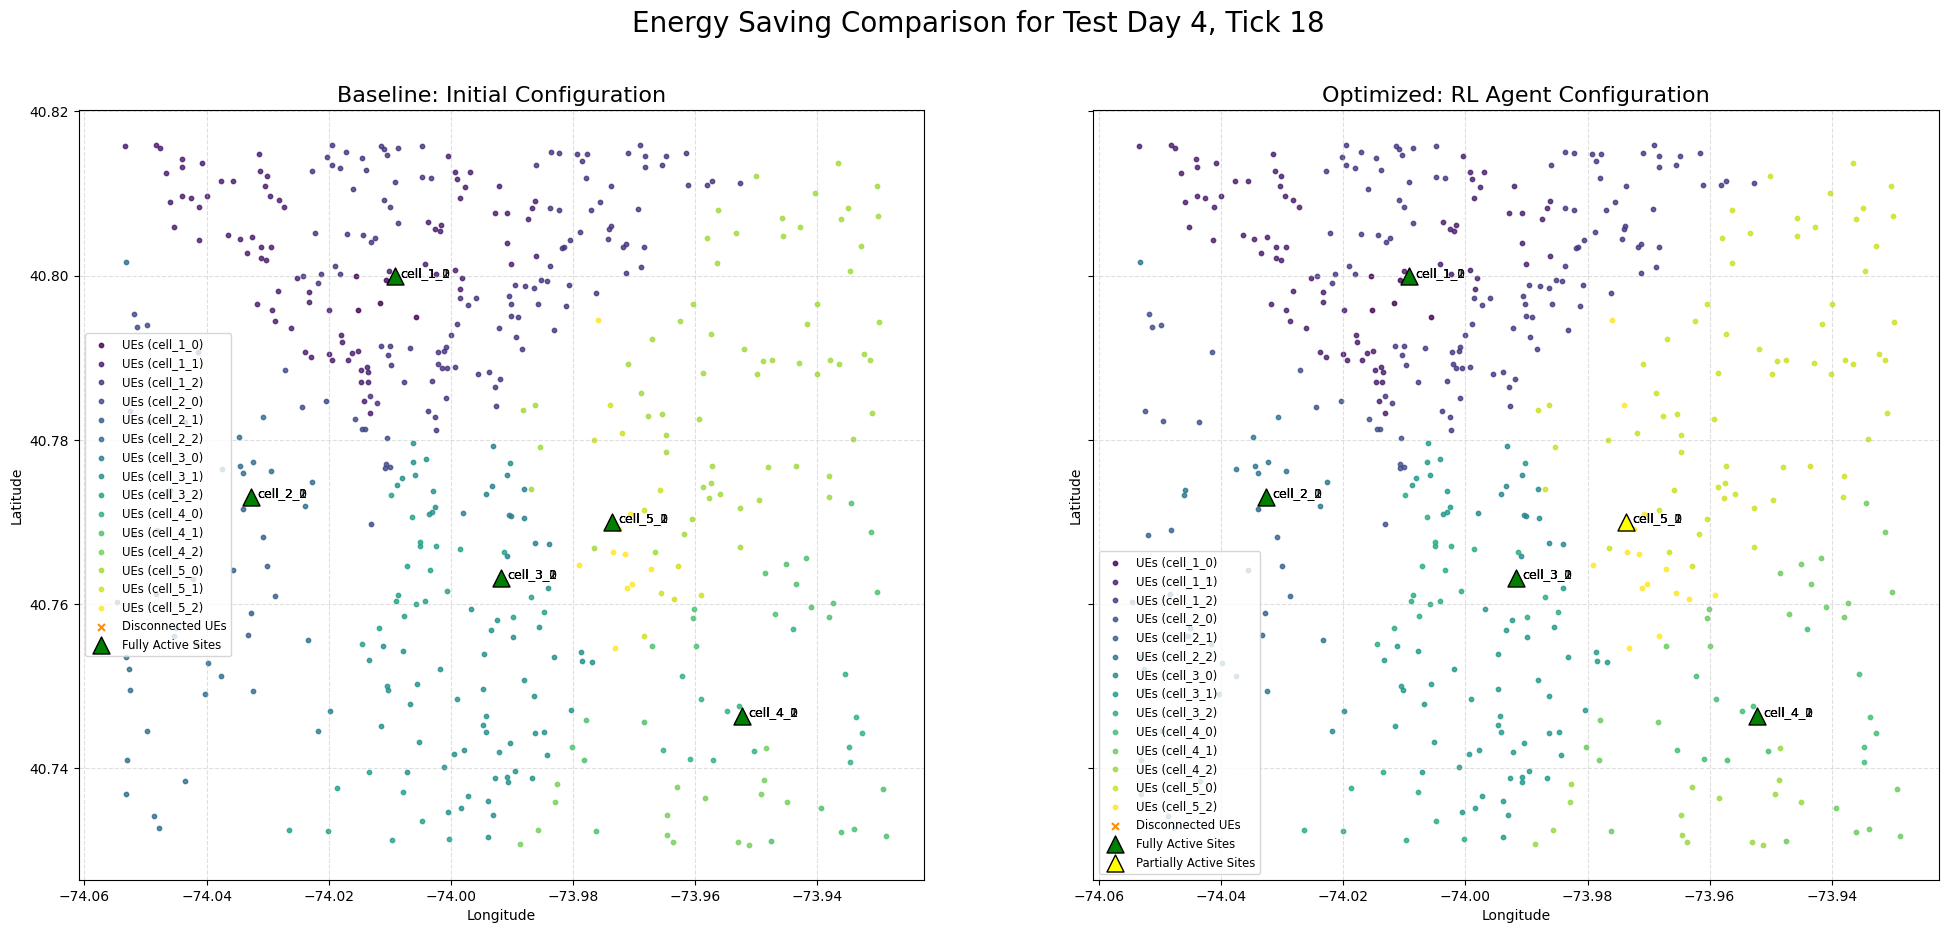

In [16]:
image_path = os.path.join(PLOT_OUTPUT_DIR, f"energy_saving_comparison_day{TEST_DAY}_tick_{TICK}.png")

# Display plot image
display(Image(filename=image_path))